# **Sprint 10**
## Análisis de test A/B 
### Hecho por: DA Mau Vilar
### -> https://github.com/mauvilar


In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as st

In [6]:
hypotheses = pd.read_csv('/datasets/hypotheses_us.csv', sep=';')
orders = pd.read_csv('/datasets/orders_us.csv')
visits = pd.read_csv('/datasets/visits_us.csv')

In [7]:
print("\n=== Head hypotheses ===\n")
print(hypotheses.head())
print("\n=== Info hypotheses ===\n")
hypotheses.info()
print()
pd.set_option('display.max_colwidth', None)  # no cortar textos
print(hypotheses['Hypothesis'])


=== Head hypotheses ===

                                                                                                               Hypothesis  \
0                                             Add two new channels for attracting traffic. This will bring 30% more users   
1                                                       Launch your own delivery service. This will shorten delivery time   
2          Add product recommendation blocks to the store's site. This will increase conversion and average purchase size   
3  Change the category structure. This will increase conversion since users will find the products they want more quickly   
4                                        Change the background color on the main page. This will increase user engagement   

   Reach  Impact  Confidence  Effort  
0      3      10           8       6  
1      2       5           4      10  
2      8       3           7       3  
3      8       3           3       8  
4      3       1           1

In [8]:
print("\n=== Head orders ===\n")
print(orders.head())
print("\n=== Info orders ===\n")
orders.info()


=== Head orders ===

   transactionId   visitorId        date  revenue group
0     3667963787  3312258926  2019-08-15     30.4     B
1     2804400009  3642806036  2019-08-15     15.2     B
2     2961555356  4069496402  2019-08-15     10.2     A
3     3797467345  1196621759  2019-08-15    155.1     B
4     2282983706  2322279887  2019-08-15     40.5     B

=== Info orders ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB


In [9]:
print("\n=== Head visits ===\n")
print(visits.head())
print("\n=== Info visits ===\n")
orders.info()


=== Head visits ===

         date group  visits
0  2019-08-01     A     719
1  2019-08-02     A     619
2  2019-08-03     A     507
3  2019-08-04     A     717
4  2019-08-05     A     756

=== Info visits ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB


### Convertir fechas a datetime

# Convertir columnas de fecha a datetime

orders['date'] = pd.to_datetime(orders['date'])
visits['date'] = pd.to_datetime(visits['date'])

print("\n=== Info orders ===\n")
orders.info()

print("\n=== Info visits ===\n")
visits.info()


## **Parte 1**
### Framework ICE

In [11]:
# Calcular el score ICE y priorizar hipótesis

# 1) Crear la columna ICE
hypotheses['ICE'] = (
    hypotheses['Impact'] * hypotheses['Confidence'] / hypotheses['Effort']
)

# 2) Ordenar
hypotheses_ice = hypotheses.sort_values(by='ICE', ascending=False)

print("\n=== Hipótesis ordenadas por ICE ===\n")
print(hypotheses_ice[['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort', 'ICE']])



=== Hipótesis ordenadas por ICE ===

                                                                                                               Hypothesis  \
8                                                        Launch a promotion that gives users discounts on their birthdays   
0                                             Add two new channels for attracting traffic. This will bring 30% more users   
7                                Add a subscription form to all the main pages. This will help you compile a mailing list   
6                                 Show banners with current offers and sales on the main page. This will boost conversion   
2          Add product recommendation blocks to the store's site. This will increase conversion and average purchase size   
1                                                       Launch your own delivery service. This will shorten delivery time   
5                                                     Add a customer review page. This 

#### **ANÁLISIS**
Según el score ICE, la hipótesis con mayor prioridad es lanzar una promoción con descuentos de cumpleaños, seguida de añadir nuevos canales de tráfico y un formulario de suscripción en todas las páginas. Estas hipótesis combinan alto impacto y alta confianza con un esfuerzo moderado.

**Cambiar el color de fondo de la página principal tiene la menor prioridad porque su impacto esperado es bajo.**

### **Framework RICE**

In [12]:
# Calcular el score RICE y priorizar hipótesis

# Crear la columna RICE
hypotheses['RICE'] = (
    hypotheses['Reach'] * hypotheses['Impact'] *
    hypotheses['Confidence'] / hypotheses['Effort']
)

# Ordenar RICE
hypotheses_rice = hypotheses.sort_values(by='RICE', ascending=False)

print("\n=== Hipótesis ordenadas por RICE ===\n")
print(hypotheses_rice[['Hypothesis', 'Reach', 'Impact', 'Confidence', 'Effort', 'ICE', 'RICE']])



=== Hipótesis ordenadas por RICE ===

                                                                                                               Hypothesis  \
7                                Add a subscription form to all the main pages. This will help you compile a mailing list   
2          Add product recommendation blocks to the store's site. This will increase conversion and average purchase size   
0                                             Add two new channels for attracting traffic. This will bring 30% more users   
6                                 Show banners with current offers and sales on the main page. This will boost conversion   
8                                                        Launch a promotion that gives users discounts on their birthdays   
3  Change the category structure. This will increase conversion since users will find the products they want more quickly   
1                                                       Launch your own delivery servi

#### **ANÁLISIS**
- ICE **da prioridad a las hipótesis con mayor relación “impacto confiable / esfuerzo”**, sin considerar a cuántos usuarios afecta.

- RICE **favorece las hipótesis que afectan a muchos usuarios.** Por eso suben el formulario de suscripción y las recomendaciones de productos, y baja la promoción de cumpleaños, que tiene buen impacto pero alcance limitado.

## **Parte 2**
### Análisis de test A/B

In [13]:
# Usuarios que aparecen en ambos grupos A y B

visitors_groups = orders.groupby('visitorId')['group'].nunique()
visitors_both = visitors_groups[visitors_groups > 1].index

print('Número de usuarios en ambos grupos:', len(visitors_both))

# Filtrar estos usuarios de orders
orders = orders[~orders['visitorId'].isin(visitors_both)]

print("\n=== Info orders después de filtrar ===\n")
orders.info()

Número de usuarios en ambos grupos: 58

=== Info orders después de filtrar ===

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1016 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1016 non-null   int64         
 1   visitorId      1016 non-null   int64         
 2   date           1016 non-null   datetime64[ns]
 3   revenue        1016 non-null   float64       
 4   group          1016 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 47.6+ KB


### **2.1**
#### --> ingreso acumulado por grupo


=== Tabla diaria con ingreso acumulado ===

        date group  orders  revenue  cum_revenue  cum_orders
0 2019-08-01     A      23   2266.6       2266.6          23
1 2019-08-01     B      17    967.2        967.2          17
2 2019-08-02     A      19   1468.3       3734.9          42
3 2019-08-02     B      23   2568.1       3535.3          40
4 2019-08-03     A      24   1815.2       5550.1          66



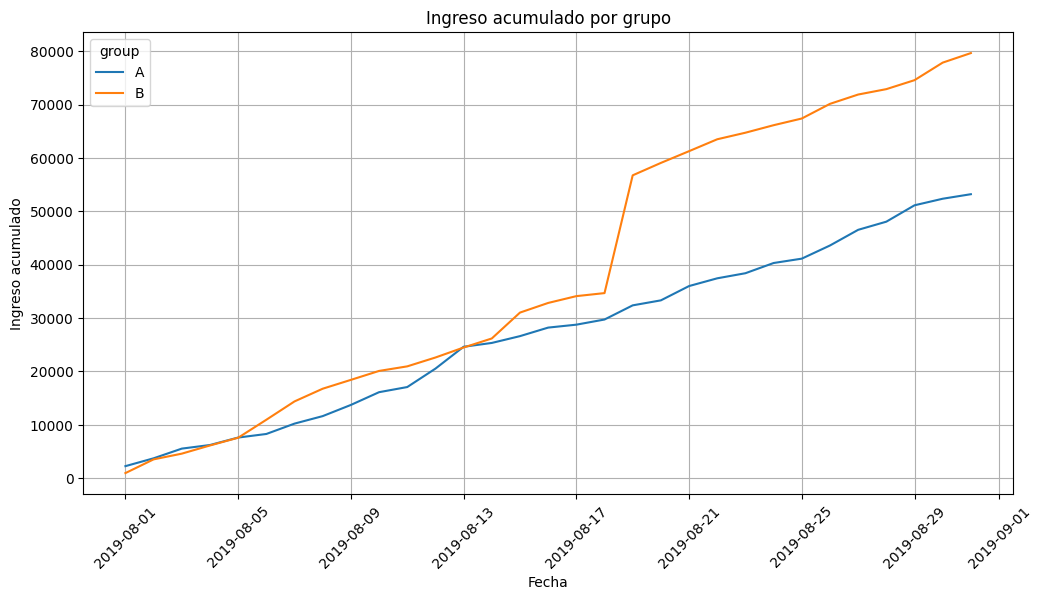

In [14]:
# Pedidos e ingresos por fecha y grupo

orders_daily = (
    orders
    .groupby(['date', 'group'], as_index=False)
    .agg({'transactionId': 'nunique', 'revenue': 'sum'})
    .rename(columns={'transactionId': 'orders'})
)

# Ingreso acumulado y pedidos acumulados
orders_daily['cum_revenue'] = orders_daily.groupby('group')['revenue'].cumsum()
orders_daily['cum_orders'] = orders_daily.groupby('group')['orders'].cumsum()

print("\n=== Tabla diaria con ingreso acumulado ===\n")
print(orders_daily.head())
print()

plt.figure(figsize=(12, 6))
sns.lineplot(data=orders_daily, x='date', y='cum_revenue', hue='group')
plt.title('Ingreso acumulado por grupo')
plt.xlabel('Fecha')
plt.ylabel('Ingreso acumulado')
plt.xticks(rotation=45)   
plt.grid(True)           
plt.show()

### **Análisis**
El ingreso acumulado del grupo B va por encima del grupo A, y **la diferencia se hace más grande a partir de mediados de agosto,** sobre todo por un salto fuerte alrededor del 18-19 de agosto.

Esto sugiere que B genera más ingresos, pero el salto brusco indica posibles pedidos atípicos que tendremos que revisar antes de sacar una conclusión definitiva.

### **2.2**
#### --> Ticket promedio acumulado por grupo



=== Tabla diaria con ticket promedio acumulado ===

        date group  orders  revenue  cum_revenue  cum_orders  cum_avg_order
0 2019-08-01     A      23   2266.6       2266.6          23      98.547826
1 2019-08-01     B      17    967.2        967.2          17      56.894118
2 2019-08-02     A      19   1468.3       3734.9          42      88.926190
3 2019-08-02     B      23   2568.1       3535.3          40      88.382500
4 2019-08-03     A      24   1815.2       5550.1          66      84.092424



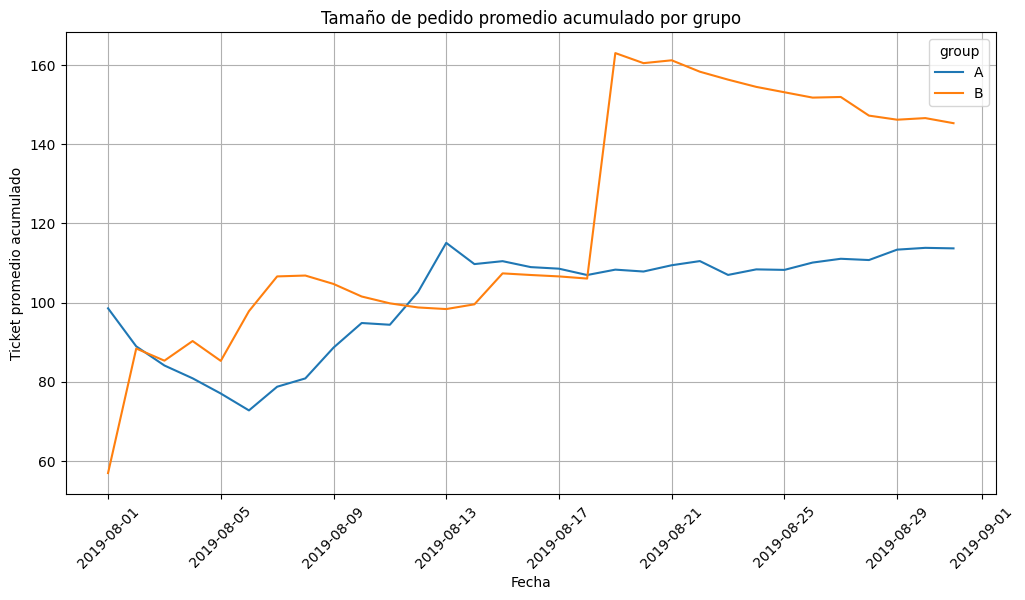

In [15]:
# Tamaño de pedido promedio acumulado (ticket medio)

orders_daily['cum_avg_order'] = (
    orders_daily['cum_revenue'] / orders_daily['cum_orders']
)

print("\n=== Tabla diaria con ticket promedio acumulado ===\n")
print(orders_daily.head())
print()


plt.figure(figsize=(12, 6))
sns.lineplot(
    data=orders_daily,
    x='date',
    y='cum_avg_order',
    hue='group'
)

plt.title('Tamaño de pedido promedio acumulado por grupo')
plt.xlabel('Fecha')
plt.ylabel('Ticket promedio acumulado')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()


### **Análisis**
Al inicio el ticket promedio acumulado del grupo A es mayor, pero después de los primeros días el grupo B lo alcanza y se mantiene por encima hasta el final.
El salto brusco alrededor del 18 de agosto sugiere uno o varios pedidos anormalmente altos en B, por lo que, aunque parece que los usuarios de B gastan más en promedio, es importante revisar y filtrar esos outliers antes de sacar una conclusión definitiva.

### **Conjeturas**
**El salto brusco alrededor del 18 de agosto podría deberse a una campaña puntual. También es posible que en esas fechas se haya lanzado alguna oferta exclusiva para B que no se ve reflejada en A**, lo que explicaría que su ticket promedio se mantenga por encima hasta el final del experimento.

### **2.3**
#### --> Diferencia relativa del ticket promedio acumulado (B vs A)


=== Diferencia relativa B vs A ===

group               A          B  rel_diff_B_vs_A
date                                             
2019-08-01  98.547826  56.894118        -0.422675
2019-08-02  88.926190  88.382500        -0.006114
2019-08-03  84.092424  85.312963         0.014514
2019-08-04  80.851948  90.272059         0.116511
2019-08-05  77.006061  85.256180         0.107136



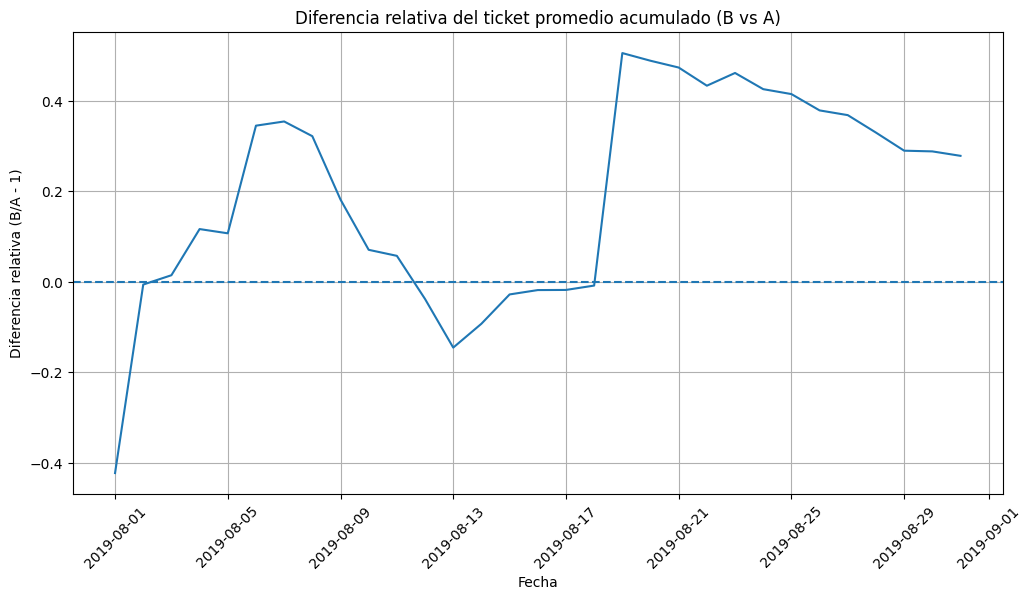

In [16]:
# Pivot: columnas A y B con el ticket promedio acumulado

avg_pivot = orders_daily.pivot(
    index='date',
    columns='group',
    values='cum_avg_order'
)

# Diferencia relativa B vs A
avg_pivot['rel_diff_B_vs_A'] = avg_pivot['B'] / avg_pivot['A'] - 1

print("\n=== Diferencia relativa B vs A ===\n")
print(avg_pivot.head())
print()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=avg_pivot,
    x=avg_pivot.index,
    y='rel_diff_B_vs_A'
)

plt.axhline(0, linestyle='--')
plt.title('Diferencia relativa del ticket promedio acumulado (B vs A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia relativa (B/A - 1)')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()


### **Análisis**
Al principio el ticket promedio acumulado del grupo B es claramente menor que el de A (−40%). A partir del 3–4 de agosto la curva se vuelve positiva y, aunque tiene algunas oscilaciones, B suele quedarse por encima de A.
Alrededor del 18–19 de agosto aparece un subida considerable (B llega a estar 50% por encima de A), lo que apunta a uno o varios pedidos atípicos en B. Después de ese pico la diferencia baja, pero al final del periodo el ticket de B sigue siendo aproximadamente 25–30% mayor que el de A.

### **Conjeturas**
**Es posible que en los primeros días del experimento el grupo B estuviera recibiendo usuarios con tickets más bajos** (por ejemplo, clientes nuevos o sensibles al precio), lo que explicaría que su ticket promedio fuera claramente menor que el de A. **A partir del 3–4 de agosto, B podría empezar a atraer un segmento de usuarios más valioso** (por cambios en el canal, la funcionalidad o alguna campaña específica), lo que hace que la diferencia se vuelva positiva.
**La subida muy marcada del 18–19 de agosto sugiere uno o varios pedidos extraordinariamente altos en B, una promoción puntual de alto valor solo para ese grupo o incluso posibles errores de registro.** Que después de ese pico la diferencia baje pero se mantenga por encima de cero indica que, aun descontando esos valores extremos, B probablemente conserve un ticket algo mayor, algo que tendremos que comprobar más adelante filtrando outliers.

### **2.4**
#### --> Tasa de conversión diaria por grupo


=== Tabla con tasa de conversión diaria ===

        date group  orders  revenue  cum_revenue  cum_orders  cum_avg_order  \
0 2019-08-01     A      23   2266.6       2266.6          23      98.547826   
1 2019-08-01     B      17    967.2        967.2          17      56.894118   
2 2019-08-02     A      19   1468.3       3734.9          42      88.926190   
3 2019-08-02     B      23   2568.1       3535.3          40      88.382500   
4 2019-08-03     A      24   1815.2       5550.1          66      84.092424   

   visits  conversion  
0     719    0.031989  
1     713    0.023843  
2     619    0.030695  
3     581    0.039587  
4     507    0.047337  


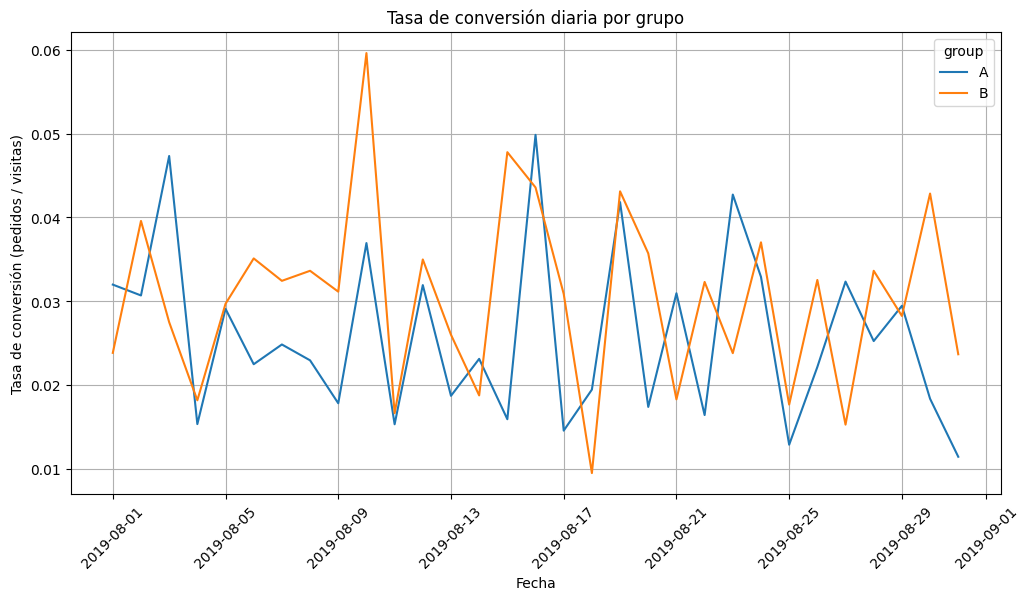

In [17]:
# Unir pedidos diarios con visitas diarias

conversion_daily = orders_daily.merge(
    visits,
    on=['date', 'group'],
    how='left'
)

# Calcular tasa de conversión diaria
conversion_daily['conversion'] = (
    conversion_daily['orders'] / conversion_daily['visits']
)

print("\n=== Tabla con tasa de conversión diaria ===\n")
print(conversion_daily.head())

# Gráfico de la tasa de conversión diaria por grupo
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=conversion_daily,
    x='date',
    y='conversion',
    hue='group'
)

plt.title('Tasa de conversión diaria por grupo')
plt.xlabel('Fecha')
plt.ylabel('Tasa de conversión (pedidos / visitas)')
plt.xticks(rotation=45)
plt.grid(True)

plt.show()


### **Análisis**
- La tasa de conversión diaria de los grupos A y B se mueve en un rango similar, aproximadamente entre 2 % y 5–6 %.

- Las líneas se cruzan muchas veces: algunos días convierte más A y otros días convierte más B.

- No se observa una ventaja estable y clara de uno de los grupos; la diferencia parece más bien ruido diario.


### **Conjeturas**
- La gran variabilidad de un día a otro puede deberse a que, con el volumen de visitas y pedidos diarios, pocos pedidos extra cambian mucho la tasa (especialmente en los picos donde B llega cerca de 0.06).

- Es posible que factores externos (día de la semana, pequeñas campañas, calidad del tráfico) estén influyendo más que la propia modificación del experimento.

- Como no hay una separación visual consistente entre A y B, es probable que la diferencia de conversión no sea estadísticamente significativa. Habrá que confirmarlo más adelante.

### **2.5**
#### --> Número de pedidos por usuario y gráfico de dispersión


=== Número de pedidos por usuario ===

   visitorId  n_orders
0    5114589         1
1    6958315         1
2   11685486         1
3   39475350         1
4   47206413         1


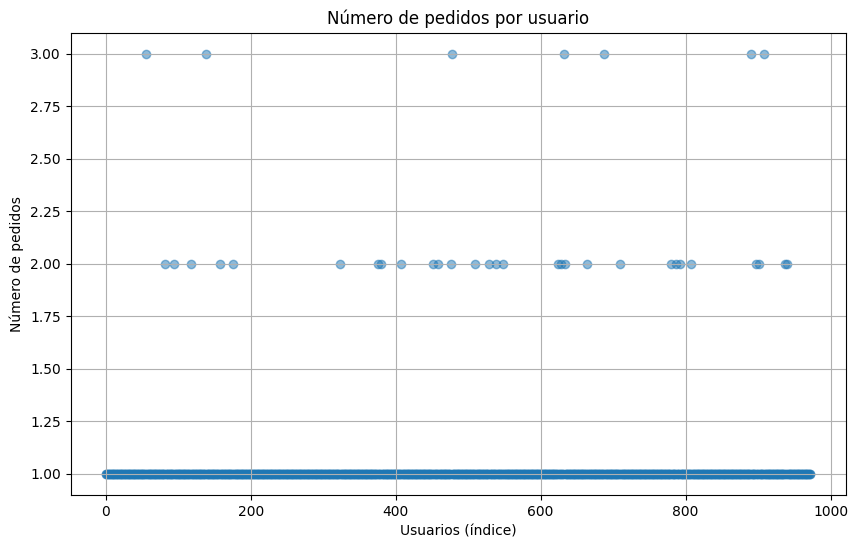

In [18]:
# Número de pedidos por usuario

orders_by_user = (
    orders.groupby('visitorId', as_index=False)
    .agg({'transactionId': 'nunique'})
    .rename(columns={'transactionId': 'n_orders'})
)

print("\n=== Número de pedidos por usuario ===\n")
print(orders_by_user.head())

# Gráfico de dispersión
plt.figure(figsize=(10, 6))
plt.scatter(
    x=range(len(orders_by_user)),
    y=orders_by_user['n_orders'],
    alpha=0.5
)

plt.title('Número de pedidos por usuario')
plt.xlabel('Usuarios (índice)')
plt.ylabel('Número de pedidos')
plt.grid(True)
plt.show()


### **Conclusiones**
- La gran **mayoría de los usuarios hizo solo 1 pedido** durante el experimento.

- Un grupo mucho más pequeño hizo 2 pedidos, y solo unos pocos casos llegan a 3 pedidos.

- La distribución está muy concentrada en 1 pedido.

### **Conjeturas**
- Es probable que muchos clientes estén probando la tienda por primera vez y todavía no haya pasado suficiente tiempo como para que repitan compra, lo que explicaría que casi todos tengan un solo pedido.

- Los pocos usuarios con 2 o 3 pedidos podrían ser clientes frecuentes, cuyo comportamiento no representa al usuario promedio. Estos clientes pueden inflar métricas como ingresos totales y ticket medio, por lo que más adelante tendrá sentido tratarlos como posibles outliers al calcular percentiles y realizar pruebas estadísticas.

### **2.6**
#### --> Percentiles 95 y 99 del número de pedidos por usuario

In [19]:
# Percentiles 95 y 99 del número de pedidos por usuario

percentiles_orders = orders_by_user['n_orders'].quantile([0.95, 0.99])

p95 = percentiles_orders.loc[0.95]
p99 = percentiles_orders.loc[0.99]

print('Percentil 95:', p95)
print('Percentil 99:', p99)


Percentil 95: 1.0
Percentil 99: 2.0


#### Punto de anomalía

In [20]:
anomaly_threshold_orders = p99  # umbral

print('Umbral de anomalía (n_orders > p99):', anomaly_threshold_orders)

Umbral de anomalía (n_orders > p99): 2.0


Consideraremos anómalos a los usuarios que hicieron más de 2 pedidos durante el experimento (n_orders > p99).

Es decir, cualquier usuario con 3 pedidos o más se tratará como outlier, ya que su comportamiento se sale del patrón del 99 % restante de los usuarios.

### **2.7**
#### --> Dispersión de precios de los pedidos

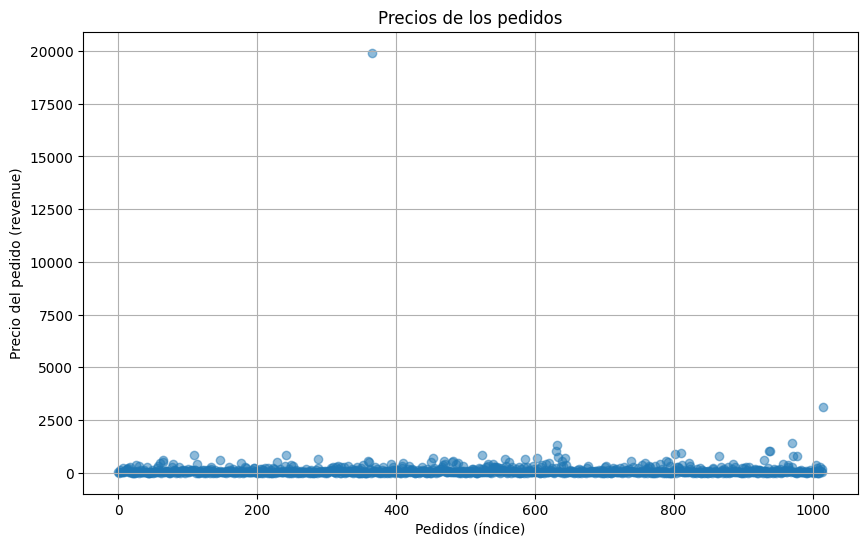

In [21]:
# Gráfico de dispersión de los precios de los pedidos

orders_price = orders.reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.scatter(
    x=orders_price.index,
    y=orders_price['revenue'],
    alpha=0.5
)

plt.title('Precios de los pedidos')
plt.xlabel('Pedidos (índice)')
plt.ylabel('Precio del pedido (revenue)')
plt.grid(True)
plt.show()


### **Conclusiones**
- La mayoría de los pedidos están en un rango de precio relativamente bajo (todos pegados a la parte de abajo del gráfico).

- Hay algunos pedidos más caros (1500–3000), pero visualmente quedan “pegados” a la nube principal.

- **Existe un solo pedido extremadamente alto (20 000)** que hace que el eje Y llegue hasta 20 000 y domine la escala. Ese pedido es un outlier clarísimo.

### **Conjeturas**
- El pedido de 20 000 podría ser:

- Un error de registro (por ejemplo, un cero de más, moneda equivocada o un monto duplicado), o una compra muy particular: cliente corporativo, pedido mayorista o carrito con muchísimos productos.

- Tendrá sentido definir un umbral de anomalía y tratar este pedido como outlier, para que el análisis estadístico sea más representativo del comportamiento típico.

### **2.8**
#### --> Percentiles 95 y 99 del precio del pedido

In [22]:
# Percentiles 95 y 99 del precio de los pedidos (revenue)

percentiles_price = orders['revenue'].quantile([0.95, 0.99])

p95_price = percentiles_price.loc[0.95]
p99_price = percentiles_price.loc[0.99]

print('Percentil 95 del precio:', p95_price)
print('Percentil 99 del precio:', p99_price)


Percentil 95 del precio: 414.275
Percentil 99 del precio: 830.3


In [23]:
anomaly_threshold_price = p99_price
print('Umbral de anomalía (precio > p99):', anomaly_threshold_price)


Umbral de anomalía (precio > p99): 830.3


El percentil 95 del precio de los pedidos es de aproximadamente 414.3 y el percentil 99 es de alrededor de 830.3.

Esto significa que el 95 % de los pedidos cuesta ≤ 414 y el 99 % cuesta ≤ 830.

Consideraré anómalos los pedidos con un precio superior a 830.3 (revenue > p99).

### **2.9**
#### --> Diferencia de conversión

In [24]:
# Pedidos totales por grupo (datos en bruto)

orders_by_group = (
    orders.groupby('group', as_index=False)
    .agg({'transactionId': 'nunique'})
    .rename(columns={'transactionId': 'n_orders'})
)

# Visitas totales por grupo
visits_by_group = (
    visits.groupby('group', as_index=False)
    .agg({'visits': 'sum'})
)

# Unir en una sola tabla
conversion_group = orders_by_group.merge(visits_by_group, on='group')
conversion_group['conversion'] = (
    conversion_group['n_orders'] / conversion_group['visits']
)

print(conversion_group)

  group  n_orders  visits  conversion
0     A       468   18736    0.024979
1     B       548   18916    0.028970


In [25]:
# Extraer valores de la tabla

row_A = conversion_group[conversion_group['group'] == 'A'].iloc[0]
row_B = conversion_group[conversion_group['group'] == 'B'].iloc[0]

n_A = row_A['visits']
n_B = row_B['visits']

orders_A = row_A['n_orders']
orders_B = row_B['n_orders']

p_A = orders_A / n_A
p_B = orders_B / n_B

# Proporción combinada
p_pool = (orders_A + orders_B) / (n_A + n_B)

# Error estándar
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))

# Estadístico z
z_stat = (p_B - p_A) / se

# p-value bilateral
p_value = 2 * (1 - st.norm.cdf(abs(z_stat)))

print('Conversión A:', p_A)
print('Conversión B:', p_B)
print('Estadístico z:', z_stat)
print('p-value:', p_value)
print()

alpha = 0.05
if p_value < alpha:
    print('Rechazamos H0: la conversión difiere entre los grupos.')
else:
    print('No rechazamos H0: no hay evidencia de que la conversión difiera entre los grupos.')

Conversión A: 0.02497865072587532
Conversión B: 0.02897018397124128
Estadístico z: 2.3899344431697442
p-value: 0.016851380434703023

Rechazamos H0: la conversión difiere entre los grupos.


### **Conclusiones**
- La conversión global del grupo **A es = 2.50 % y la del grupo B es = 2.90 %.**

- El estadístico de prueba es **z = 2.39 y el p-value = 0.0169, que es menor que α = 0.05.**

- Por lo tanto, **rechazamos H0** y concluimos que la conversión de los grupos A y B es diferente.

- **Como la conversión de B es mayor, el grupo B convierte significativamente mejor que el grupo A (unos 0.4 puntos porcentuales,  un 15 % más en términos relativos).**

### **Conjeturas**
- Es probable que la funcionalidad probada en el grupo B esté mejorando ligeramente la probabilidad de compra (por ejemplo, haciendo más fácil el proceso de pedido o resaltando mejor las ofertas), lo que explica su conversión más alta.

- Aunque la diferencia en porcentaje parece pequeña, al multiplicarla por el volumen total de visitas puede traducirse en un incremento considerable de pedidos e ingresos a largo plazo.

### **2.10**
#### --> Significancia estadística de la diferencia en el tamaño promedio de pedido

In [26]:
# Tamaño de pedido por grupo (muestras)

revenue_A = orders[orders['group'] == 'A']['revenue']
revenue_B = orders[orders['group'] == 'B']['revenue']

print('Media A:', revenue_A.mean())
print('Media B:', revenue_B.mean())

alpha = 0.05

# t-test de dos muestras independientes (Welch)
results = st.ttest_ind(revenue_A, revenue_B, equal_var=False)

print('Estadístico t:', results.statistic)
print('p-value:', results.pvalue)
print()

if results.pvalue < alpha:
    print('Rechazamos H0: el tamaño promedio de pedido difiere entre A y B.')
else:
    print('No rechazamos H0: no hay evidencia de diferencia en el tamaño promedio de pedido.')


Media A: 113.70085470085469
Media B: 145.34890510948907
Estadístico t: -0.8344812341397616
p-value: 0.4043438730780975

No rechazamos H0: no hay evidencia de diferencia en el tamaño promedio de pedido.


### **Conclusiones**
- El tamaño promedio de pedido del grupo A es = 113.7 y el del grupo B es = 145.3.

- El t-test da un estadístico t = −0.83 y un p-value ≈ 0.40, que es mayor que a = 0.05.

- Por lo tanto, **no rechazamos H0:** con los datos en bruto no hay evidencia estadísticamente significativa de que el tamaño promedio de pedido sea diferente entre los grupos A y B, a pesar de que la media de B es algo mayor.

### **Conjeturas**
- Es posible que la diferencia observada en las medias (B > A) se deba sobre todo al azar y a la alta variabilidad de los importes, más que a un efecto real de la nueva funcionalidad.

- Sabemos que existen pedidos muy caros (outliers) que pueden inflar la media y aumentar la dispersión, lo que reduce la capacidad de la prueba para detectar diferencias reales.

- También puede ocurrir que el cambio probado en B afecte principalmente a la conversión (probabilidad de comprar) y no tanto al importe de cada pedido, por lo que el tamaño de pedido se mantenga similar entre grupos.

- Por eso tiene sentido **repetir esta prueba más adelante con datos filtrados (sin outliers)** para comprobar si, una vez controlado el ruido, aparece alguna diferencia real en el ticket promedio.

### **2.11**
#### --> Significancia estadística de la diferencia en la conversión entre los grupos sin ouliers

In [27]:
# Número de pedidos por usuario

orders_by_user = (
    orders.groupby('visitorId', as_index=False)
    .agg({'transactionId': 'nunique'})
    .rename(columns={'transactionId': 'n_orders'})
)

# Percentiles del nº de pedidos
p95_orders, p99_orders = orders_by_user['n_orders'].quantile([0.95, 0.99])

# Usuarios "anómalos" por nº de pedidos
users_many_orders = orders_by_user[orders_by_user['n_orders'] > p99_orders]['visitorId']

# Percentiles del precio
percentiles_price = orders['revenue'].quantile([0.95, 0.99])
p95_price = percentiles_price.loc[0.95]
p99_price = percentiles_price.loc[0.99]

# Filtrar pedidos:
#    - excluir usuarios con muchos pedidos
#    - excluir pedidos con precio > p99_price

orders_filtered = orders[
    (~orders['visitorId'].isin(users_many_orders)) &
    (orders['revenue'] <= p99_price)
]

print('Pedidos originales:', len(orders))
print('Pedidos filtrados:', len(orders_filtered))

Pedidos originales: 1016
Pedidos filtrados: 986


**Conversión por grupo con datos filtrados**

In [28]:
# Pedidos filtrados por grupo

orders_filt_by_group = (
    orders_filtered.groupby('group', as_index=False)
    .agg({'transactionId': 'nunique'})
    .rename(columns={'transactionId': 'n_orders'})
)

# Visitas totales por grupo (no cambian)
visits_by_group = (
    visits.groupby('group', as_index=False)
    .agg({'visits': 'sum'})
)

conversion_group_filt = orders_filt_by_group.merge(visits_by_group, on='group')
conversion_group_filt['conversion'] = (
    conversion_group_filt['n_orders'] / conversion_group_filt['visits']
)

print(conversion_group_filt)


  group  n_orders  visits  conversion
0     A       448   18736    0.023911
1     B       538   18916    0.028442


**z-test de dos proporciones**

In [29]:
# Extraer filas A y B

row_A_f = conversion_group_filt[conversion_group_filt['group'] == 'A'].iloc[0]
row_B_f = conversion_group_filt[conversion_group_filt['group'] == 'B'].iloc[0]

n_A_f = row_A_f['visits']
n_B_f = row_B_f['visits']

orders_A_f = row_A_f['n_orders']
orders_B_f = row_B_f['n_orders']

p_A_f = orders_A_f / n_A_f
p_B_f = orders_B_f / n_B_f

# Proporción combinada
p_pool_f = (orders_A_f + orders_B_f) / (n_A_f + n_B_f)

# Error estándar
se_f = np.sqrt(p_pool_f * (1 - p_pool_f) * (1/n_A_f + 1/n_B_f))

# Estadístico z
z_stat_f = (p_B_f - p_A_f) / se_f

# p-value bilateral
p_value_f = 2 * (1 - st.norm.cdf(abs(z_stat_f)))

print('Conversión A (filtrado):', p_A_f)
print('Conversión B (filtrado):', p_B_f)
print('Estadístico z (filtrado):', z_stat_f)
print('p-value (filtrado):', p_value_f)
print()

alpha = 0.05
if p_value_f < alpha:
    print('Rechazamos H0: la conversión difiere entre los grupos (datos filtrados).')
else:
    print('No rechazamos H0: no hay evidencia de que la conversión difiera entre los grupos (datos filtrados).')


Conversión A (filtrado): 0.02391118701964133
Conversión B (filtrado): 0.028441530979065342
Estadístico z (filtrado): 2.7523779403956374
p-value (filtrado): 0.005916419709985243

Rechazamos H0: la conversión difiere entre los grupos (datos filtrados).


### **Conclusiones**
- Tras filtrar outliers, la conversión del grupo A es = 2.39 % y la del grupo B es = 2.84 %.

- El z-stat es 2.75 y el p-value = 0.0059, que es menor que a = 0.05.

- Por lo tanto, rechazamos H0 también con los datos filtrados:

- **La conversión del grupo B sigue siendo significativamente mayor que la del grupo A.**

### **Conjeturas**
- El hecho de que, aun eliminando usuarios y pedidos atípicos, la diferencia siga siendo significativa sugiere que el efecto de la versión B es robusto y no depende solo de unos pocos casos extremos.

- La mejora absoluta en conversión es pequeña (unas décimas de punto porcentual), pero en términos relativos implica que B convierte claramente mejor que A, lo que a gran escala puede traducirse en un aumento relevante de pedidos e ingresos.

- Esto refuerza la idea de que la funcionalidad probada en el grupo B facilita que los usuarios completen la compra, y que el cambio podría ser una buena candidata para implementarse de forma permanente, siempre que no tenga efectos negativos en otras métricas (por ejemplo, ticket medio o experiencia de usuario).

### **2.12**
#### --> Significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos sin outliers

**t-test con datos filtrados**

In [30]:
# Tamaño de pedido por grupo con datos filtrados

revenue_A_f = orders_filtered[orders_filtered['group'] == 'A']['revenue']
revenue_B_f = orders_filtered[orders_filtered['group'] == 'B']['revenue']

print('Media A (filtrado):', revenue_A_f.mean())
print('Media B (filtrado):', revenue_B_f.mean())

alpha = 0.05

results_f = st.ttest_ind(revenue_A_f, revenue_B_f, equal_var=False)

print('Estadístico t (filtrado):', results_f.statistic)
print('p-value (filtrado):', results_f.pvalue)
print()

if results_f.pvalue < alpha:
    print('Rechazamos H0: el tamaño promedio de pedido difiere entre A y B (datos filtrados).')
else:
    print('No rechazamos H0: no hay evidencia de diferencia en el tamaño promedio de pedido (datos filtrados).')


Media A (filtrado): 102.89642857142857
Media B (filtrado): 99.61412639405205
Estadístico t (filtrado): 0.3806878590320744
p-value (filtrado): 0.7035214166868313

No rechazamos H0: no hay evidencia de diferencia en el tamaño promedio de pedido (datos filtrados).


### **Conclusiones**
- Con datos filtrados, el tamaño promedio de pedido es de = 102.9 para el grupo A y = 99.6 para el grupo B.

- El estadístico t ≈ 0.38 y el p-value ≈ 0.70, muy por encima de a = 0.05.

- Por lo tanto, **no rechazamos H0:**

- **No hay evidencia estadísticamente significativa de diferencia en el tamaño promedio de pedido entre A y B cuando excluimos outliers.**

### **Conjeturas**

- La pequeña diferencia en las medias (A ligeramente mayor que B) probablemente se debe al azar y a la variabilidad natural de los importes, no a un efecto real de la versión B.

- Esto confirma que la funcionalidad del grupo B no cambia el ticket promedio, sino que su impacto principal está en la conversión (más usuarios compran, pero con un importe similar).

- También sugiere que las diferencias que veíamos con los datos en bruto estaban influidas por pedidos extremos, al quitarlos, el comportamiento “típico” de los usuarios de ambos grupos es muy parecido en cuanto al tamaño de pedido.

## Recomendación final

Opción 1: **parar la prueba y considerar al grupo B como líder.**

Por qué: 

--> En conversión, **el grupo B es consistentemente mejor:**

Datos brutos: A ≈ 2.50 %, B ≈ 2.90 %, p-value ≈ 0.017 < 0.05.

Datos filtrados: A ≈ 2.39 %, B ≈ 2.84 %, p-value ≈ 0.006 < 0.05.

--> **La diferencia es estadísticamente significativa incluso después de quitar outliers.**

En el tamaño promedio de pedido (ticket):

Con datos brutos y filtrados, los p-values (~0.40 y ~0.70) son > 0.05.

--> **No hay diferencias significativas entre A y B en el importe de cada pedido.**

Conclusión de negocio:

**El grupo B genera más pedidos con el mismo ticket promedio.**

Eso implica más ingresos totales sin empeorar la calidad de los pedidos.

### **Conjeturas finales**
**La funcionalidad probada en B probablemente mejora el embudo de compra (más usuarios completan el pedido), pero no cambia cuánto gastan. Dado que el efecto en conversión es pequeño pero estable y estadísticamente significativo, tiene sentido detener el experimento y adoptar la versión B como nueva versión principal, monitorizando las métricas en producción por si cambian las condiciones del negocio.**